# Tutorial: E/S Analysis

Paul, write this quick tutorial

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import smfbursts as smf
import smfbursts.datamodel.multifit as smfit

In [2]:
raw = smf.photonHDF5.load('data/dsdna_d7_d17_50_50_1.hdf5')
data = smf.photonHDF5.regularize_dets(raw)

In [3]:
dbg = smf.fretfactory.make_bg(data, func=smf.bg.exp_mlefit, auto_threshold=True, tail_min=5e-4, F_bg=2.0)
dbs = smf.fretfactory.make_burst_search(bg=dbg['bg'], streams=(smf.PhSel('0ex'), smf.PhSel('1ex1em')), m=10, F=6.0)
gate = smf.make_geq_gate(dbs['NphDex_bg'], 30.0) & smf.make_geq_gate(dbs['NphAA_bg'], 30.0)

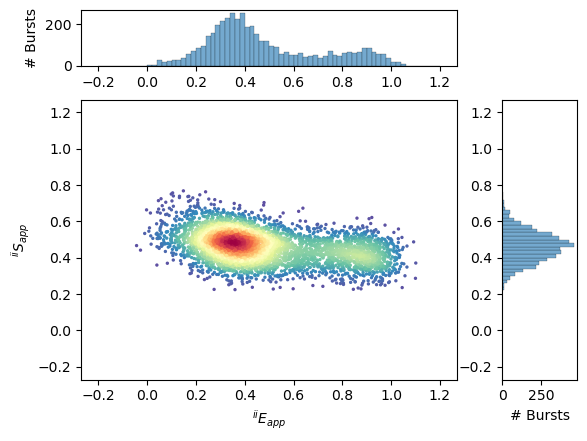

In [4]:
axs, cout, xout, yout = smf.plot.jointplot(data, dbs['E_bg'], dbs['S_bg'], gate=gate, 
                                           cplot_kwargs=smf.fretfactory.ALEXdefaults['scatter',('point_func',smf.plot.density_kde),('cmap','Spectral_r')], 
                                           hplot_kwargs=smf.fretfactory.ALEXdefaults['histbar', ('bins', 'ratio_bins')])

(-0.2, 1.2)

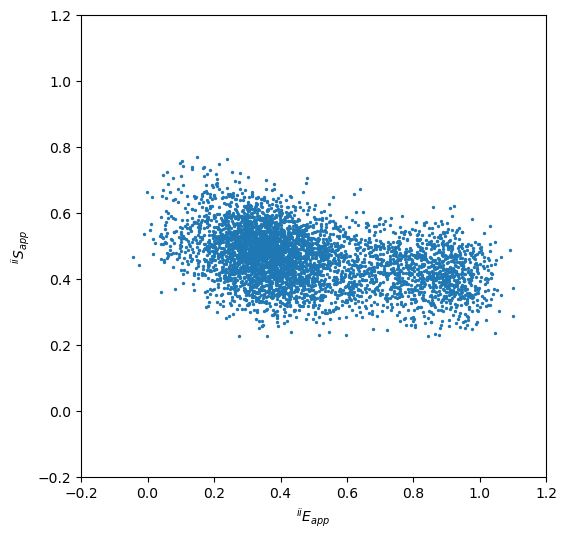

In [5]:
fig, ax = plt.subplots(1,1, figsize=(6,6))
smf.plot.scatter(data, dbs['E_bg'], dbs['S_bg'], gate=gate, ax=ax, **smf.fretfactory.ALEXdefaults['scatter'])
ax.set_xlim([-0.2, 1.2])
ax.set_ylim([-0.2, 1.2])

(<matplotlib.collections.PolyCollection at 0x7c18ec5d2270>,
 Text(0.5, 0, '$^{ii}E_{app}$'),
 Text(0, 0.5, '$^{ii}S_{app}$'))

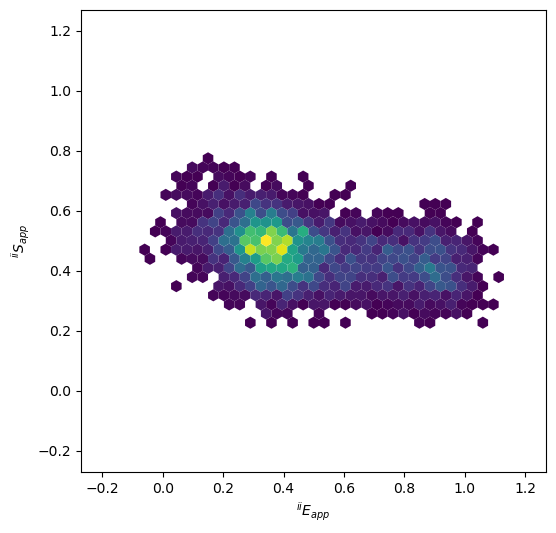

In [6]:
fig, ax = plt.subplots(1,1, figsize=(6,6))
smf.plot.hexbin(data, dbs['E_bg'], dbs['S_bg'], gate=gate, ax=ax, **smf.fretfactory.ALEXdefaults['hexbin'])

As is good practice, remember to get/and or print the citations when you are done:

In [7]:
smf.print_citations()

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X.
    FRETBursts: An open source toolkit for analysis of freely-diffusing Single-
    molecule FRET. PLoS ONE 11, 1–27 (2016).
2. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M.
    Monitoring conformational dynamics of a single molecule by selective
    fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561
    (1998).
3. Nir, E. et al. Shot-noise limited single-molecule FRET histograms: Comparison
    between theory and experiments. Journal of Physical Chemistry B 110,
    22103–22124 (2006).
